# Analysis
Network analysis of Bluesky discourse around machine translation.

**Research questions:**
1. **Sentiment & framing** — Do people talk about MT as a tool, a threat, or both?
2. **Professional impact discourse** — How do working translators discuss MT's effect on their careers?
3. **Utility vs. displacement tension** — Do people acknowledge MT's utility while lamenting professional erosion?

## Setup

In [1]:
!pip -q install networkx matplotlib pandas

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
import numpy as np
from collections import Counter

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
DATA_DIR = '/content/drive/MyDrive/bluesky-data/'

In [21]:
df = pd.read_csv(DATA_DIR + 'posts_clean.csv')
df_raw = pd.read_csv(DATA_DIR + 'posts_raw.csv')   # needed to resolve reply URIs
df_profiles = pd.read_csv(DATA_DIR + 'author_profiles.csv')
df_graph = pd.read_csv(DATA_DIR + 'graph.csv')
df_reply_raw = pd.read_csv(DATA_DIR + 'reply_edges.csv')

print(f"Posts (clean): {len(df)}")
print(f"Posts (raw):   {len(df_raw)}")
print(f"Profiles:      {len(df_profiles)}")
print(f"Graph edges:   {len(df_graph)} ({df_graph['type'].value_counts().to_dict()})")
print(f"Reply edges:   {len(df_reply_raw)}")

Posts (clean): 3767
Posts (raw):   8244
Profiles:      1009
Graph edges:   118701 ({'follows': 118701})
Reply edges:   4479


## Network construction

In [22]:
# Build directed graph
G = nx.from_pandas_edgelist(
    df_graph, source='source', target='target',
    edge_attr='type', create_using=nx.DiGraph()
)

# Attach node attributes
user_type_map = dict(zip(df['handle'], df['user_type']))
post_count_map = df['handle'].value_counts().to_dict()

for node in G.nodes():
    G.nodes[node]['user_type'] = user_type_map.get(node, 'unknown')
    G.nodes[node]['post_count'] = post_count_map.get(node, 0)
    G.nodes[node]['in_posts'] = node in user_type_map

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 80421
Edges: 118671


## Basic graph statistics

In [23]:
print("=" * 45)
print("FULL GRAPH")
print("=" * 45)
print(f"Nodes:   {G.number_of_nodes()}")
print(f"Edges:   {G.number_of_edges()}")
print(f"Density: {nx.density(G):.6f}")

# Subgraph: only nodes that appear as post authors
post_authors = set(df['handle'])
G_posts = G.subgraph(post_authors).copy()

print(f"\n{'='*45}")
print("POST AUTHORS SUBGRAPH")
print("=" * 45)
print(f"Nodes:   {G_posts.number_of_nodes()}")
print(f"Edges:   {G_posts.number_of_edges()}")
print(f"Density: {nx.density(G_posts):.4f}")

wcc = list(nx.weakly_connected_components(G_posts))
print(f"Weakly connected components: {len(wcc)}")
print(f"Largest component size:      {max(len(c) for c in wcc)}")

FULL GRAPH
Nodes:   80421
Edges:   118671
Density: 0.000018

POST AUTHORS SUBGRAPH
Nodes:   1291
Edges:   1433
Density: 0.0009
Weakly connected components: 422
Largest component size:      792


## Centrality

In [42]:
# Degree centrality (normalized)
degree_centrality = nx.degree_centrality(G_posts)
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:15]

print("Top 15 by degree centrality (normalized):")
print(f"  {'handle':<42} {'degree_c':>9}  type")
print("  " + "-" * 62)
for handle, score in top_degree:
    utype = user_type_map.get(handle, 'unknown')
    print(f"  {handle:<42} {score:>9.4f}  {utype}")

Top 15 by degree centrality (normalized):
  handle                                      degree_c  type
  --------------------------------------------------------------
  handle.invalid                                0.0829  general
  globalvisibility.bsky.social                  0.0357  general
  i-like-to-moob-it.bsky.social                 0.0295  general
  insideloc.bsky.social                         0.0295  professional
  rankednews.bsky.social                        0.0217  professional
  render87.bsky.social                          0.0194  general
  gametranslator.bsky.social                    0.0163  professional
  creative-xl8.bsky.social                      0.0163  professional
  linguacaps.bsky.social                        0.0155  professional
  promptslinger.bsky.social                     0.0155  general
  subtleuk.bsky.social                          0.0140  professional
  cdomingueztrad.com                            0.0132  professional
  aulet.es                   

In [25]:
# Reply subgraph — resolve target URIs using posts_raw (wider than posts_clean)
uri_to_handle = dict(zip(df_raw['uri'], df_raw['handle']))
df_reply_resolved = df_reply_raw.copy()
df_reply_resolved['target'] = df_reply_resolved['target_uri'].map(uri_to_handle)
df_reply_resolved = df_reply_resolved.dropna(subset=['target'])

print(f"Reply edges total:    {len(df_reply_raw)}")
print(f"Reply edges resolved: {len(df_reply_resolved)}")

G_reply = nx.from_pandas_edgelist(
    df_reply_resolved, source='source', target='target',
    create_using=nx.DiGraph()
)

in_degree_reply = dict(G_reply.in_degree())
top_reply = sorted(in_degree_reply.items(), key=lambda x: x[1], reverse=True)[:10]

print(f"\nReply network — nodes: {G_reply.number_of_nodes()}, edges: {G_reply.number_of_edges()}")
print(f"\nTop 10 most replied-to users:")
print(f"  {'handle':<42} {'replies':>7}  type")
print("  " + "-" * 60)
for handle, deg in top_reply:
    utype = user_type_map.get(handle, 'unknown')
    print(f"  {handle:<42} {deg:>7}  {utype}")

Reply edges total:    4479
Reply edges resolved: 4479

Reply network — nodes: 2713, edges: 3227

Top 10 most replied-to users:
  handle                                     replies  type
  ------------------------------------------------------------
  tobyfox.undertale.com                          326  general
  bcmerchant.bsky.social                          53  general
  barleybap.bsky.social                           43  professional
  eurosky.social                                  35  general
  blazingwaters.myatproto.social                  29  general
  tamslator.eurosky.social                        23  general
  peloriemate.net                                 22  general
  liabelle.me                                     22  general
  gandersocial.ca                                 21  unknown
  daiz.moe                                        21  professional


In [26]:
# Betweenness centrality on post-authors subgraph (bridges between communities)
betweenness = nx.betweenness_centrality(G_posts, normalized=True)
top_between = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 by betweenness centrality (bridges between groups):")
print(f"  {'handle':<42} {'between':>8}  type")
print("  " + "-" * 62)
for handle, score in top_between:
    utype = user_type_map.get(handle, 'unknown')
    print(f"  {handle:<42} {score:>8.4f}  {utype}")

Top 10 by betweenness centrality (bridges between groups):
  handle                                      between  type
  --------------------------------------------------------------
  insideloc.bsky.social                        0.0057  professional
  jemediatranslation.bsky.social               0.0056  professional
  awkwardteapot.bsky.social                    0.0055  professional
  thewrongsideoftime.bsky.social               0.0051  general
  linguacaps.bsky.social                       0.0048  professional
  cargodin.bsky.social                         0.0046  professional
  xythar.bsky.social                           0.0043  general
  rnaboursiii.bsky.social                      0.0043  general
  spiritusnox.bsky.social                      0.0040  tech
  cammyille.bsky.social                        0.0037  general


In [41]:
# Closeness centrality — computed on LCC only (meaningless on disconnected graphs)
lcc_nodes_centrality = max(nx.weakly_connected_components(G_posts), key=len)
G_posts_lcc = G_posts.subgraph(lcc_nodes_centrality).copy()

closeness = nx.closeness_centrality(G_posts_lcc)
top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:15]

print(f"Closeness centrality computed on LCC ({G_posts_lcc.number_of_nodes()} nodes):")
print(f"  {'handle':<42} {'closeness':>10}  type")
print("  " + "-" * 64)
for handle, score in top_closeness:
    utype = user_type_map.get(handle, 'unknown')
    print(f"  {handle:<42} {score:>10.4f}  {utype}")

Closeness centrality computed on LCC (792 nodes):
  handle                                      closeness  type
  ----------------------------------------------------------------
  creative-xl8.bsky.social                       0.0634  professional
  subtleuk.bsky.social                           0.0631  professional
  avue.bsky.social                               0.0624  professional
  loekalization.bsky.social                      0.0622  tech
  scanomendez.bsky.social                        0.0617  general
  apolline.bsky.social                           0.0593  professional
  cdomingueztrad.com                             0.0592  professional
  atanet.org                                     0.0585  professional
  brivaiglesias.bsky.social                      0.0582  professional
  linguacaps.bsky.social                         0.0580  professional
  ollicarreira.bsky.social                       0.0576  tech
  jemediatranslation.bsky.social                 0.0571  professional
  

## Community detection - Louvain

In [32]:
# Community detection — Louvain, Greedy Modularity, FluidC
G_posts_undirected = G_posts.to_undirected()

isolates = list(nx.isolates(G_posts_undirected))
G_posts_connected = G_posts_undirected.copy()
G_posts_connected.remove_nodes_from(isolates)
print(f"Nodes after removing isolates: {G_posts_connected.number_of_nodes()}")

# ── Louvain ──────────────────────────────────────────────────────
communities_louvain = nx.community.louvain_communities(G_posts_connected, seed=42)
communities_louvain = sorted(communities_louvain, key=len, reverse=True)

# ── Greedy Modularity ─────────────────────────────────────────────
communities_greedy = list(nx.community.greedy_modularity_communities(G_posts_connected))
communities_greedy = sorted(communities_greedy, key=len, reverse=True)

# ── FluidC ───────────────────────────────────────────────────────
# FluidC requires a single connected component and a fixed k
lcc_nodes = max(nx.connected_components(G_posts_connected), key=len)
G_lcc = G_posts_connected.subgraph(lcc_nodes).copy()
k_fluid = len(communities_louvain)  # use Louvain's k as reference
communities_fluid = list(nx.community.asyn_fluidc(G_lcc, k=k_fluid, seed=42))
communities_fluid = sorted(communities_fluid, key=len, reverse=True)


Nodes after removing isolates: 926

Method                    k    Modularity  Notes
-----------------------------------------------------------------
Louvain                  74        0.7416  k discovered automatically
Greedy Modularity        78        0.7275  k discovered automatically
FluidC                   74        0.5694  k fixed = Louvain k, LCC only (792 nodes)


In [36]:
from itertools import islice

In [37]:
print("Running Girvan-Newman (this may take a few minutes)...")
gn_gen = nx.community.girvan_newman(G_lcc)
best_gn_communities = None
best_gn_mod = -1
for partition in islice(gn_gen, len(communities_louvain) + 2):
  mod = nx.community.modularity(G_lcc, partition)
  if mod > best_gn_mod:
    best_gn_mod = mod
    best_gn_communities = list(partition)
best_gn_communities = sorted(best_gn_communities, key=len, reverse=True)
print("Girvan-Newman done.")

Running Girvan-Newman (this may take a few minutes)...
Girvan-Newman done.


In [38]:
# ── Comparison ───────────────────────────────────────────────────
mod_louvain = nx.community.modularity(G_posts_connected, communities_louvain)
mod_greedy  = nx.community.modularity(G_posts_connected, communities_greedy)
mod_fluid   = nx.community.modularity(G_lcc, communities_fluid)

print(f"\n{'Method':<22} {'k':>4}  {'Modularity':>12}  Notes")
print("-" * 65)
print(f"{'Louvain':<22} {len(communities_louvain):>4}  {mod_louvain:>12.4f}  k discovered automatically")
print(f"{'Greedy Modularity':<22} {len(communities_greedy):>4}  {mod_greedy:>12.4f}  k discovered automatically")
print(f"{'FluidC':<22} {len(communities_fluid):>4}  {mod_fluid:>12.4f}  k fixed = Louvain k, LCC only ({G_lcc.number_of_nodes()} nodes)")
print(f"{'Girvan-Newman':<22} {len(best_gn_communities):>4}  {best_gn_mod:>12.4f}  best modularity partition, LCC only")


Method                    k    Modularity  Notes
-----------------------------------------------------------------
Louvain                  74        0.7416  k discovered automatically
Greedy Modularity        78        0.7275  k discovered automatically
FluidC                   74        0.5694  k fixed = Louvain k, LCC only (792 nodes)
Girvan-Newman            28        0.7074  best modularity partition, LCC only


In [39]:
# Use Louvain as primary for downstream analysis
communities = communities_louvain

In [40]:
# Assign community ID to posts and inspect each community
node_community = {}
for i, community in enumerate(communities):
    for node in community:
        node_community[node] = i

df['community'] = df['handle'].map(node_community)

print("User type breakdown + sample posts per community (top 5):\n")
for i in range(min(5, len(communities))):
    comm_df = df[df['community'] == i]
    if comm_df.empty:
        continue
    print(f"── Community {i+1} ({len(communities[i])} nodes, {len(comm_df)} posts) ──")
    print(comm_df['user_type'].value_counts().to_string())
    print("Sample posts:")
    for t in comm_df['text_clean'].sample(min(3, len(comm_df)), random_state=42).tolist():
        print(f"  • {t[:110]}")
    print()

User type breakdown + sample posts per community (top 5):

── Community 1 (124 nodes, 301 posts) ──
user_type
professional    147
general         136
tech             18
Sample posts:
  • Con la llegada de la #MTPE desaforada, ya nadie se inscribe ni se apunta a congresos, representaciones o actua
  • My eyebrows crawled so far up my head when I saw that 5-6 months thing. What translator with 7seas is taking s
  • Human translator here. While commendable (seriously!) there is a downside of clauses like this: AI checkers th

── Community 2 (120 nodes, 222 posts) ──
user_type
general         194
professional     23
tech              5
Sample posts:
  • It's what I do for some of those translated openings I post. Since I use Google Translate more often than not,
  • As someone who studies translation, I gotta recognize my standing as an ''old man yelling at cloud'' with thes
  • I started learning Japanese because the number of things I wanted to read in Japanese was growing exponentiall


## Visualizations

Reply network after filtering: 885 nodes, 1003 edges


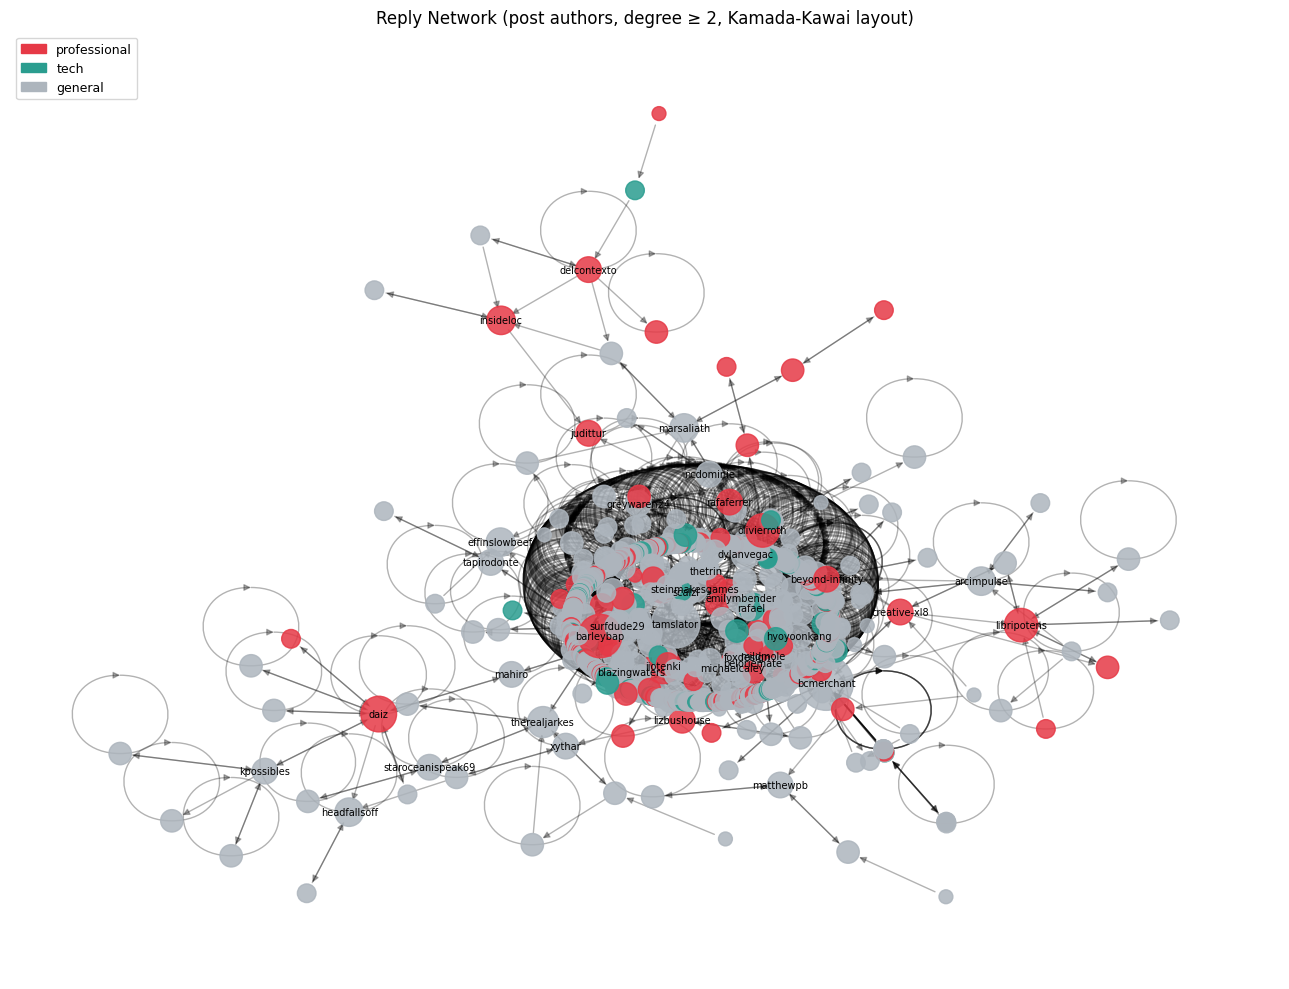

In [43]:
# Reply network — filter to post authors only, min degree >= 2
color_map = {
    'professional': '#e63946',
    'tech':         '#2a9d8f',
    'general':      '#adb5bd',
    'unknown':      '#dee2e6',
}

# Keep only nodes that are post authors with at least 2 connections
post_authors = set(df['handle'])
nodes_to_keep = [n for n in G_reply.nodes()
                 if n in post_authors and G_reply.degree(n) >= 2]
G_reply_filtered = G_reply.subgraph(nodes_to_keep).copy()

print(f"Reply network after filtering: {G_reply_filtered.number_of_nodes()} nodes, {G_reply_filtered.number_of_edges()} edges")

pos = nx.kamada_kawai_layout(G_reply_filtered)
in_deg = dict(G_reply_filtered.in_degree())
node_colors = [color_map.get(user_type_map.get(n, 'unknown'), '#dee2e6') for n in G_reply_filtered.nodes()]
node_sizes  = [100 + in_deg.get(n, 0) * 80 for n in G_reply_filtered.nodes()]

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_nodes(G_reply_filtered, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_reply_filtered, pos, alpha=0.3, arrows=True, arrowsize=10, ax=ax)

# Label nodes with degree >= 3
top_handles = {n for n in G_reply_filtered.nodes() if in_deg.get(n, 0) >= 3}
labels = {n: n.split('.')[0] for n in top_handles}
nx.draw_networkx_labels(G_reply_filtered, pos, labels=labels, font_size=7, ax=ax)

legend_patches = [Patch(color=c, label=t) for t, c in color_map.items() if t != 'unknown']
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax.set_title("Reply Network (post authors, degree ≥ 2, Kamada-Kawai layout)", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(DATA_DIR + 'reply_network.png', dpi=150, bbox_inches='tight')
plt.show()

Community graph after filtering: 494 nodes, 943 edges


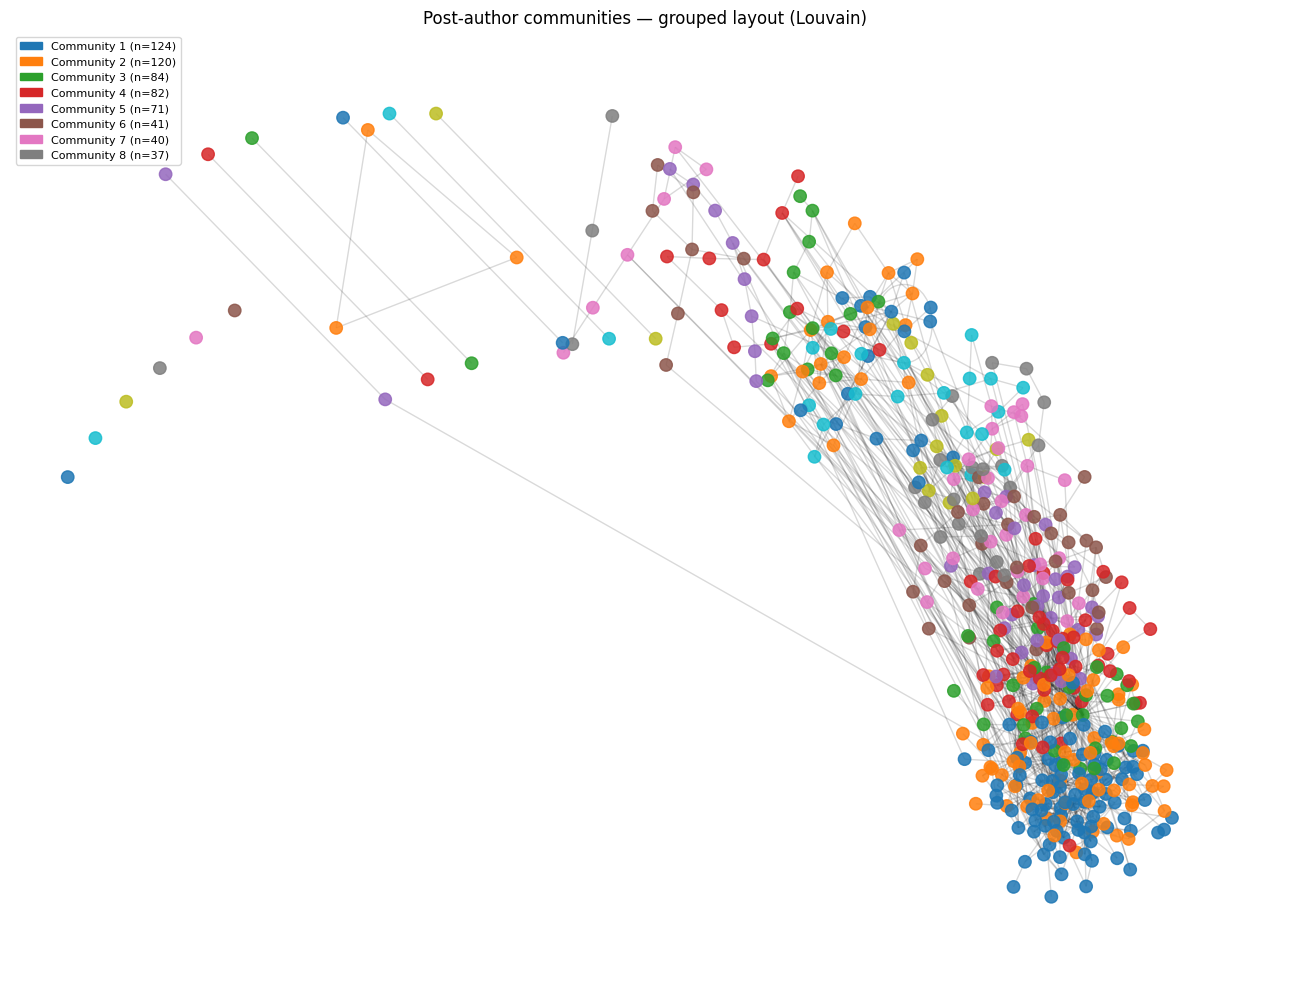

In [45]:
# Community graph — post authors only, min degree >= 2, grouped by community
community_colors = plt.cm.tab10.colors

nodes_to_keep = [n for n in G_posts_connected.nodes()
                 if n in post_authors and G_posts_connected.degree(n) >= 2]
G_comm_filtered = G_posts_connected.subgraph(nodes_to_keep).copy()
print(f"Community graph after filtering: {G_comm_filtered.number_of_nodes()} nodes, {G_comm_filtered.number_of_edges()} edges")

# Position all communities in a circle, spring layout within each
pos = {}
n_communities = len(communities)
centres = {i: (np.cos(2 * np.pi * i / n_communities) * 3,
               np.sin(2 * np.pi * i / n_communities) * 3)
           for i in range(n_communities)}

for i, community in enumerate(communities):
    members = [n for n in community if n in G_comm_filtered.nodes()]
    if not members:
        continue
    sub = G_comm_filtered.subgraph(members)
    sub_pos = nx.spring_layout(sub, seed=42, k=0.5)
    cx, cy = centres[i]
    for node, (x, y) in sub_pos.items():
        pos[node] = (x * 0.6 + cx, y * 0.6 + cy)

# Only draw nodes that got a position (safety check)
nodes_with_pos = [n for n in G_comm_filtered.nodes() if n in pos]
G_draw = G_comm_filtered.subgraph(nodes_with_pos).copy()

node_comm_colors = [
    community_colors[node_community.get(n, 0) % len(community_colors)]
    for n in G_draw.nodes()
]

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_nodes(G_draw, pos, node_color=node_comm_colors, node_size=80, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_draw, pos, alpha=0.15, ax=ax)

legend_patches = [
    Patch(color=community_colors[i % len(community_colors)], label=f"Community {i+1} (n={len(communities[i])})")
    for i in range(min(8, len(communities)))
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=8)
ax.set_title("Post-author communities — grouped layout (Louvain)", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(DATA_DIR + 'communities.png', dpi=150, bbox_inches='tight')
plt.show()

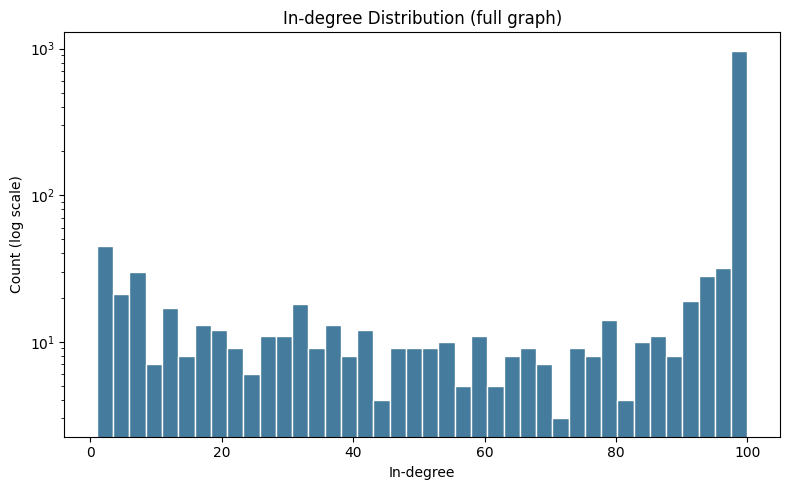

In [31]:
# In-degree distribution
in_degrees = [d for _, d in G.in_degree() if d > 0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(in_degrees, bins=40, color='#457b9d', edgecolor='white', log=True)
ax.set_xlabel("In-degree")
ax.set_ylabel("Count (log scale)")
ax.set_title("In-degree Distribution (full graph)")
plt.tight_layout()
plt.savefig(DATA_DIR + 'degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()